In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

In [2]:
counts = pd.read_csv('../data/count_matrix_ML499M1-S1.tsv', sep = '\t', index_col=0)
expression = pd.read_csv('../data/expression_matrix_ML499M1-S1.tsv', sep = '\t', index_col=0)

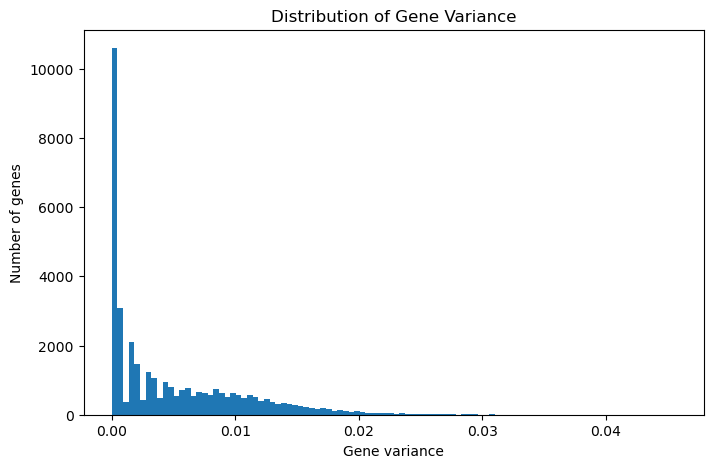

In [7]:
import matplotlib.pyplot as plt

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(expression)

gene_var = pd.Series(X_scaled.var(axis=0), index=expression.columns)

# 2. Histogram of variance
plt.figure(figsize=(8,5))
plt.hist(gene_var, bins=100)
plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
# plt.yscale('log')
plt.title("Distribution of Gene Variance")
plt.show()

In [8]:
# Pick top 1500 genes
top_n = 1500
top_genes = gene_var.sort_values(ascending=False).head(top_n).index

expression_var = expression[top_genes]
expression_var

,COMMD5,ZNF740,VPS25,ZNF513,ENO2,CALCOCO2,AP1G2,AC024075.3,ZNF511,PTER,...,HYI.AS1,CRACR2B,AL512625.1,B9D2,ADGRB1,LINC02259,KNDC1,AC027644.3,HIRIP3,ZNF554
TTTCATCAGCACGATT-1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ACCATTAAGTTAGAGG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CATAGACTCGGCTAGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTCATTCAGTGCACGC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
CTCCAAACAGAAACGT-1,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GCTGATCCAAAGGTAC-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TTTCCGGGTAGGATCC-1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
AAACCAACATGTTGTG-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
TGGTCAGTCACACAGT-1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(expression_var)

pca = PCA(n_components=50)
expression_pca = pca.fit_transform(X_scaled)

print("Original shape:", expression_var.shape)
print("Reduced shape:", expression_pca.shape)

Original shape: (1440, 1500)
Reduced shape: (1440, 50)


(array([ 30438., 214846., 284996., 299134., 269822., 254570., 218768.,
        196282., 219624.,  85120.]),
 array([-0.79450572, -0.61505515, -0.43560458, -0.25615401, -0.07670343,
         0.10274714,  0.28219771,  0.46164828,  0.64109886,  0.82054943,
         1.        ]),
 <BarContainer object of 10 artists>)

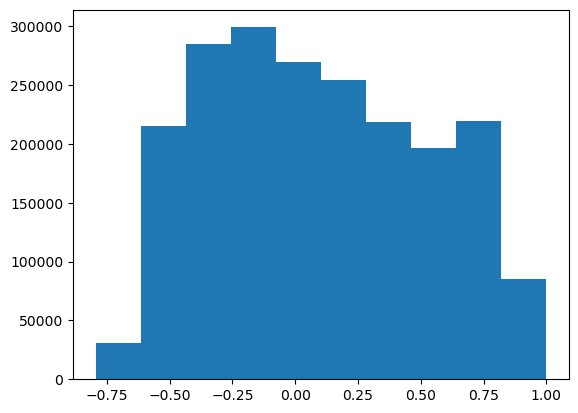

In [21]:

pc_names = [f"PC{i+1}" for i in range(expression_pca.shape[1])]
expression_df_pca = pd.DataFrame(expression_pca, columns=pc_names, index=expression_var.index)
expression_pearson_matrix = expression_df_pca.T.corr(method='pearson')
expression_pearson_flat = expression_pearson_matrix.to_numpy().ravel()
plt.hist(expression_pearson_flat)


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_matrix = cosine_similarity(expression_df_pca)

# Convert to DataFrame for readability
cosine_matrix = pd.DataFrame(
    cosine_matrix,
    index=expression_df_pca.index,
    columns=expression_df_pca.index
)

print(cosine_matrix)


                    TTTCATCAGCACGATT-1  ACCATTAAGTTAGAGG-1  \
TTTCATCAGCACGATT-1            1.000000            0.252018   
ACCATTAAGTTAGAGG-1            0.252018            1.000000   
CATAGACTCGGCTAGC-1            0.289285            0.775690   
TTCATTCAGTGCACGC-1            0.262601            0.763522   
CTCCAAACAGAAACGT-1            0.149936           -0.156475   
...                                ...                 ...   
GCTGATCCAAAGGTAC-1            0.261502            0.724074   
TTTCCGGGTAGGATCC-1           -0.193206           -0.046691   
AAACCAACATGTTGTG-1            0.313703            0.787192   
TGGTCAGTCACACAGT-1           -0.133092           -0.252124   
TCCTGTTCAATTGAGA-1            0.301033            0.747051   

                    CATAGACTCGGCTAGC-1  TTCATTCAGTGCACGC-1  \
TTTCATCAGCACGATT-1            0.289285            0.262601   
ACCATTAAGTTAGAGG-1            0.775690            0.763522   
CATAGACTCGGCTAGC-1            1.000000            0.917046   
TTCATTC

Number of duplicate columns: 18660


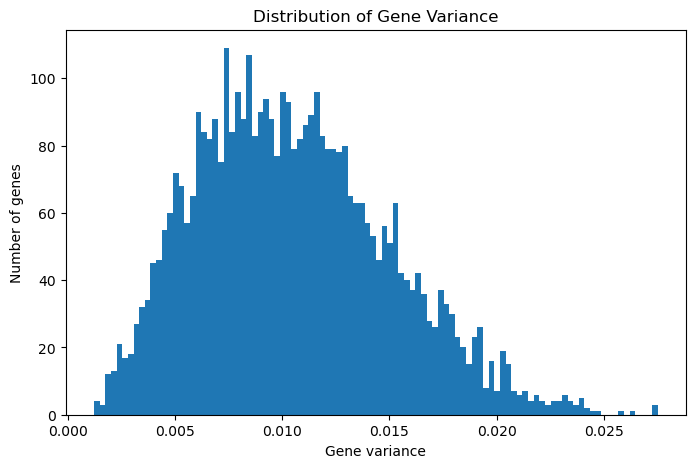

In [27]:
duplicate_mask = counts.T.duplicated()

print("Number of duplicate columns:", duplicate_mask.sum())

# Keep only unique columns (because of the windows causing many to be identical)
counts_unique = counts.loc[:, ~duplicate_mask]


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(counts_unique)

gene_var = pd.Series(X_scaled.var(axis=0), index=counts_unique.columns)


# 2. Histogram of variance
plt.figure(figsize=(8,5))
plt.hist(gene_var, bins=100)
plt.xlabel("Gene variance")
plt.ylabel("Number of genes")
# plt.yscale('log')
plt.title("Distribution of Gene Variance")
plt.show()



In [28]:
# Pick top 1500 genes
top_n = 1500
top_genes = gene_var.sort_values(ascending=False).head(top_n).index

counts_var = counts_unique[top_genes]

Original shape: (1440, 1500)
Reduced shape: (1440, 50)


(array([  4216.,  76392., 291200., 507684., 537978., 393946., 199004.,
         57368.,   4296.,   1516.]),
 array([-0.76411001, -0.58769901, -0.41128801, -0.23487701, -0.05846601,
         0.117945  ,  0.294356  ,  0.470767  ,  0.647178  ,  0.823589  ,
         1.        ]),
 <BarContainer object of 10 artists>)

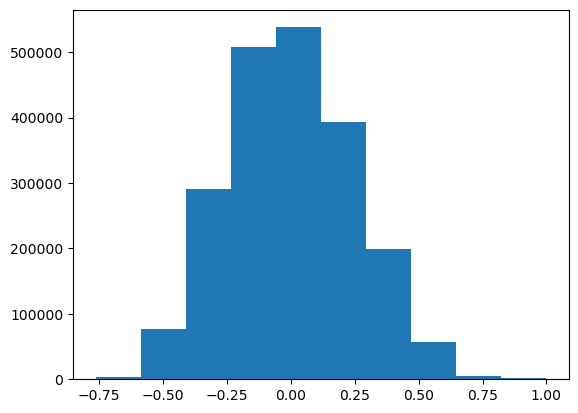

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(counts_var)

pca = PCA(n_components=50)
counts_pca = pca.fit_transform(X_scaled)

print("Original shape:", counts_var.shape)
print("Reduced shape:", counts_pca.shape)


pc_names = [f"PC{i+1}" for i in range(counts_pca.shape[1])]
counts_df_pca = pd.DataFrame(counts_pca, columns=pc_names, index=counts_var.index)
counts_pearson_matrix = counts_df_pca.T.corr(method='pearson')
counts_pearson_flat = counts_pearson_matrix.to_numpy().ravel()
plt.hist(counts_pearson_flat)


In [ ]:
pearson_matrix_exp = expression.T.corr(method='pearson')

print(pearson_matrix_exp)

                    TTTCATCAGCACGATT-1  ACCATTAAGTTAGAGG-1  \
TTTCATCAGCACGATT-1            1.000000            0.577147   
ACCATTAAGTTAGAGG-1            0.577147            1.000000   
CATAGACTCGGCTAGC-1            0.494825            0.494319   
TTCATTCAGTGCACGC-1            0.518058            0.521193   
CTCCAAACAGAAACGT-1            0.760800            0.559726   
...                                ...                 ...   
GCTGATCCAAAGGTAC-1            0.274774            0.284653   
TTTCCGGGTAGGATCC-1            0.569924            0.545769   
AAACCAACATGTTGTG-1            0.517827            0.435184   
TGGTCAGTCACACAGT-1            0.864108            0.584982   
TCCTGTTCAATTGAGA-1            0.472596            0.471986   

                    CATAGACTCGGCTAGC-1  TTCATTCAGTGCACGC-1  \
TTTCATCAGCACGATT-1            0.494825            0.518058   
ACCATTAAGTTAGAGG-1            0.494319            0.521193   
CATAGACTCGGCTAGC-1            1.000000            0.716790   
TTCATTC

Text(0, 0.5, 'Pearson')

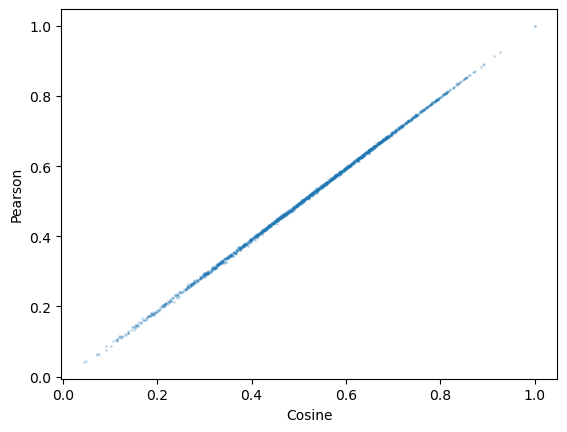

In [ ]:
cosine_exp = cosine_matrix_exp.to_numpy().ravel()
pearson_exp = pearson_matrix_exp.to_numpy().ravel()

cosine_sub = cosine_exp[subset_indices]
pearson_sub = pearson_exp[subset_indices]

import matplotlib.pyplot as plt

plt.scatter(cosine_sub, pearson_sub, alpha = 0.2, s = 1)
plt.xlabel("Cosine")
plt.ylabel("Pearson")

(array([ 11134.,  66982., 153894., 283826., 421478., 487024., 390458.,
        204876.,  50918.,   3010.]),
 array([0.01552789, 0.1139751 , 0.21242231, 0.31086952, 0.40931674,
        0.50776395, 0.60621116, 0.70465837, 0.80310558, 0.90155279,
        1.        ]),
 <BarContainer object of 10 artists>)

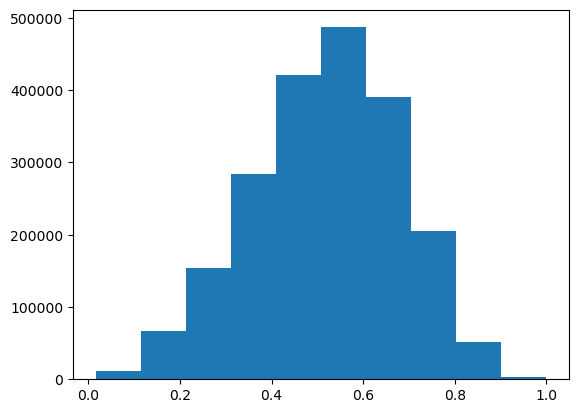

In [ ]:
plt.hist(cosine_exp)